In [1]:
import numpy as np
import itertools
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import colorcet as cc
from matplotlib.colors import ListedColormap
import matplotlib as mpl

from utils import savefig

plt.rcParams['font.size'] = 14

mpl.rcParams['svg.fonttype'] = 'none'

In [12]:
# noise
noise_vecs = []
noise_vars = []
cosine_sims = []

for i in range(1):
    noise_vec1 = []
    noise_var1 = []
    noise_vec = np.random.randn(64)
    noise_vec = (noise_vec - np.mean(noise_vec)) / np.std(noise_vec)
    noise_vec1.append(noise_vec)
    noise_var1.append(np.var(noise_vec))
    for j in range(63):
        noise_vec = noise_vec + np.random.randn(64)
        noise_vec = (noise_vec - np.mean(noise_vec)) / np.std(noise_vec)
        noise_vec1.append(noise_vec)
        noise_var1.append(np.var(noise_vec))
    noise_vec1 = np.array(noise_vec1)
    noise_vecs.append(noise_vec1)
    noise_vars.append(noise_var1)
    cosine_sims.append(cosine_similarity(noise_vec1))

# print(noise_vecs[0])

noise_vecs = np.mean(noise_vecs, axis=0)
noise_vars = np.mean(noise_vars, axis=0)
cosine_sims = np.mean(cosine_sims, axis=0)



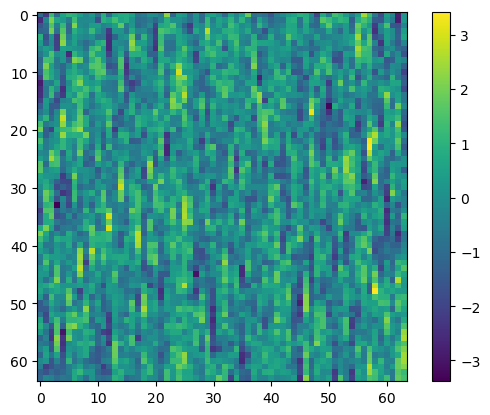

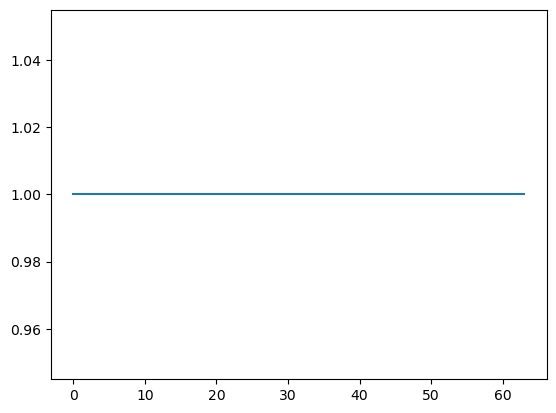

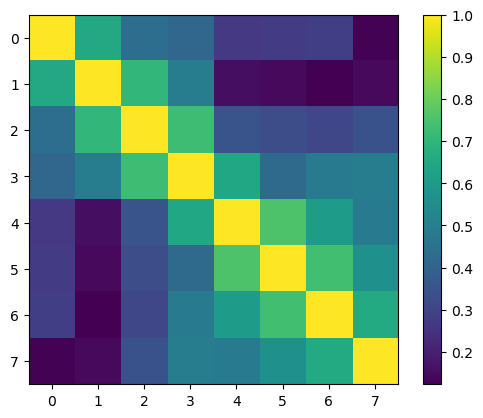

In [58]:


plt.imshow(noise_vecs)
plt.colorbar()
plt.show()
plt.close()

plt.plot(noise_vars)
plt.show()
plt.close()

plt.imshow(cosine_sims[:8, :8])
plt.colorbar()
plt.show()
plt.close()

In [2]:
dim = 41
x = np.linspace(-3, 3+6/(dim-2)*((int(dim)+1) % 2), dim)
sigma = 0.2
std = 0.4
gaussian_vec = (1.0 / np.sqrt(2 * np.pi * sigma ** 2)) * np.exp(-0.5 * (x / sigma) ** 2)
gaussian_vec = (gaussian_vec - np.mean(gaussian_vec)) / np.std(gaussian_vec) * std
print(np.std(gaussian_vec))
gaussian_vec = np.roll(gaussian_vec, -63//2)
gaussian_vecs = []
for i in range(63):
    gaussian_vec = np.roll(gaussian_vec, 1)
    gaussian_vecs.append(gaussian_vec)
gaussian_vecs = np.array(gaussian_vecs)

cosine_sims = cosine_similarity(gaussian_vecs)
print(gaussian_vecs[0])

0.4
[-0.14439008 -0.14439008 -0.14439008 -0.14439008 -0.14439008 -0.14439008
 -0.14439008 -0.14439008 -0.14439008 -0.14439008 -0.14439008 -0.14439008
 -0.14439008 -0.14439008 -0.14439008 -0.14439008 -0.14439008 -0.14439008
 -0.14439008 -0.14439008 -0.14439008 -0.14439008 -0.14439005 -0.14438824
 -0.14431911 -0.14282455 -0.12471269 -0.00346619  0.43066738  1.19265856
  1.62691158  1.19265856  0.43066738 -0.00346619 -0.12471269 -0.14282455
 -0.14431911 -0.14438824 -0.14439005 -0.14439008 -0.14439008]


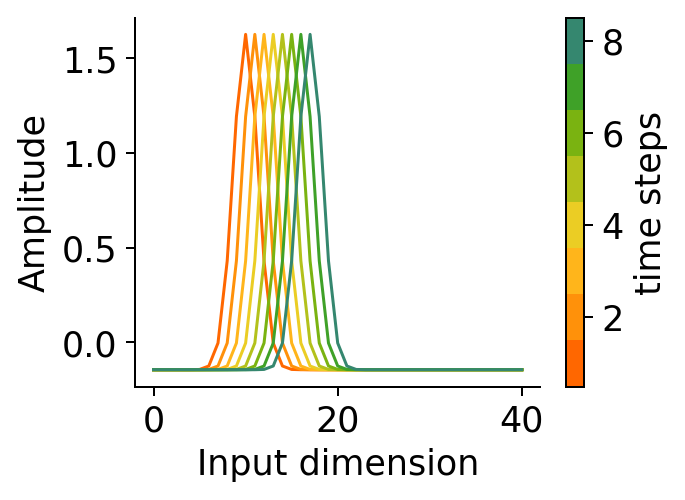

10


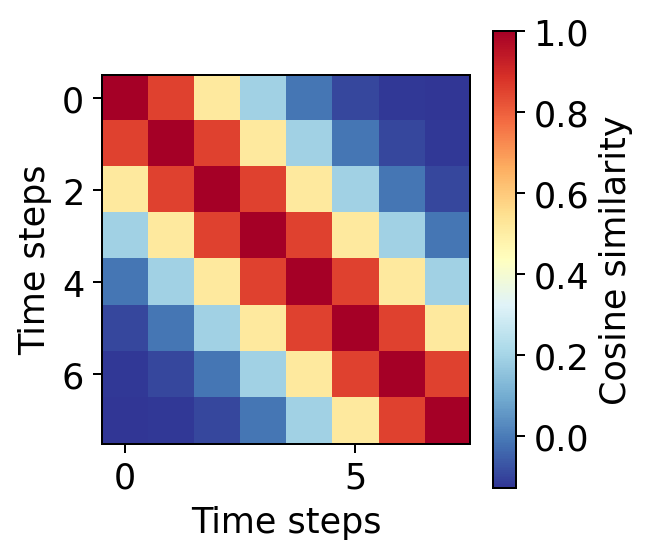

In [4]:
plt.figure(figsize=(4, 3), dpi=180)
n_steps = 8
colors = np.array([cc.cm.rainbow.reversed()(i) for i in np.linspace(0.1, 0.8, n_steps)])
starting_point = 21
for i in range(starting_point, starting_point+n_steps):
    plt.plot(np.arange(dim), gaussian_vecs[i], color=colors[i-starting_point], linewidth=1.2)
plt.xlabel("Input dimension")
plt.ylabel("Amplitude")
ax = plt.gca()
cmap = ListedColormap(colors)
norm = plt.Normalize(vmin=0.5, vmax=0.5+n_steps)
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ticks=np.arange(2, n_steps+1, 2), label="time steps", ax=ax)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
savefig("./figures/fig5", "fig5A", format="svg", close=False)
plt.show()
plt.close()
print(np.argmax(gaussian_vecs[-1]))

plt.figure(figsize=(3.3, 3.3), dpi=180)
plt.imshow(cosine_sims[:8, :8], cmap="RdYlBu_r")
plt.xlabel("Time steps")
plt.ylabel("Time steps")
plt.colorbar(label="Cosine similarity")
plt.show()
plt.close()

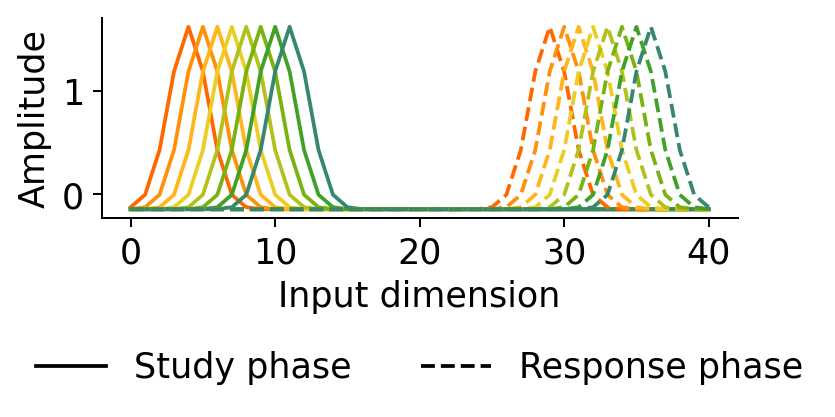

10


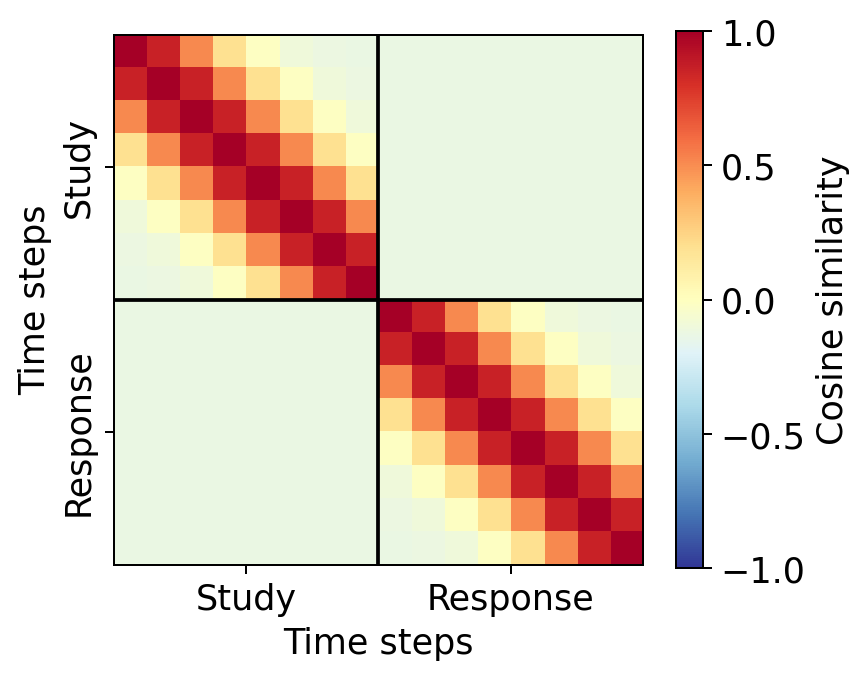

In [5]:
plt.figure(figsize=(5, 5), dpi=180)
n_steps = 8
colors = np.array([cc.cm.rainbow.reversed()(i) for i in np.linspace(0.1, 0.8, n_steps)])
starting_point = 15
for i in range(starting_point, starting_point+n_steps):
    plt.plot(np.arange(dim), gaussian_vecs[i], color=colors[i-starting_point])
starting_point2 = 40
for i in range(starting_point2, starting_point2+n_steps):
    plt.plot(np.arange(dim), gaussian_vecs[i], color=colors[i-starting_point2], linestyle="--")
from matplotlib.lines import Line2D

# Create custom legend handles for study and response phase
legend_elements = [
    Line2D([0], [0], color="black", linestyle="-", label="Study phase"),
    Line2D([0], [0], color="black", linestyle="--", label="Response phase"),
]
plt.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(0.5, -0.9), borderaxespad=0., frameon=False, ncol=2)

plt.xlabel("Input dimension")
plt.ylabel("Amplitude")
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
savefig("./figures/exfig6", "exfig6A", format="svg", close=False)
plt.show()
plt.close()
print(np.argmax(gaussian_vecs[-1]))

sims_data = np.zeros((16, 16))
sims_data[:8, :8] = cosine_sims[starting_point:starting_point+n_steps, starting_point:starting_point+n_steps]
sims_data[8:, :8] = cosine_sims[starting_point2:starting_point2+n_steps, starting_point:starting_point+n_steps]
sims_data[:8, 8:] = cosine_sims[starting_point:starting_point+n_steps, starting_point2:starting_point2+n_steps]
sims_data[8:, 8:] = cosine_sims[starting_point2:starting_point2+n_steps, starting_point2:starting_point2+n_steps]
plt.figure(figsize=(5, 4.5), dpi=180)
plt.imshow(sims_data, cmap="RdYlBu_r", vmin=-1, vmax=1)
plt.xlabel("Time steps")
plt.ylabel("Time steps")
# Set custom tick positions and labels for study and response phases
tick_positions = [3.5, 11.5]  # Centers of the two 8x8 blocks
tick_labels = ['Study', 'Response']
plt.xticks([3.5, 11.5], tick_labels)
plt.yticks([3.5, 11.5], tick_labels, rotation=90, va='center')
plt.gca().set_xticks([7.5], minor=True)
plt.gca().set_yticks([7.5], minor=True)
plt.gca().tick_params(which='minor', length=0)
plt.gca().grid(visible=True, which='minor', color='black', linewidth=1.5)

plt.colorbar(label="Cosine similarity", shrink=0.8)
plt.tight_layout()
savefig("./figures/exfig6", "exfig6B", format="svg", close=False)
plt.show()
plt.close()

[[0 0 0 0]
 [0 0 0 1]
 [0 0 1 0]
 [0 0 1 1]
 [0 1 0 0]
 [0 1 0 1]
 [0 1 1 0]
 [0 1 1 1]
 [1 0 0 0]
 [1 0 0 1]
 [1 0 1 0]
 [1 0 1 1]
 [1 1 0 0]
 [1 1 0 1]
 [1 1 1 0]
 [1 1 1 1]]


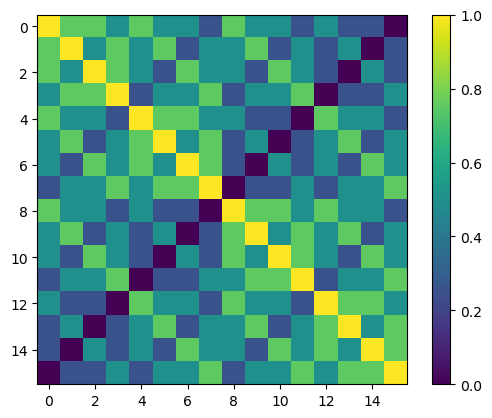

In [20]:
feature_dim = 2
num_features = 4
item_features = list(itertools.product(range(feature_dim), repeat=num_features))
item_features = np.array(item_features)
print(item_features)

item_vecs = []
for i in range(len(item_features)):
    vec = np.zeros(feature_dim * num_features)
    for j in range(num_features):
        vec[j * feature_dim + item_features[i, j]] = 1
    item_vecs.append(vec)
item_vecs = np.array(item_vecs)

cosine_sims = cosine_similarity(item_vecs)
plt.imshow(cosine_sims)
plt.colorbar()
plt.show()
plt.close()


In [44]:
import numpy as np
import random
from copy import deepcopy

class HierarchicalBinaryPatterns(object):

    def __init__(self, dim=32, n1=4, n2=4, n3=4, p1=.2, p2=.05):
        self.dim = dim
        self.n1 = n1
        self.n2 = n2
        self.n3 = n3
        self.p1 = p1
        self.p2 = p2
        # useful constants
        self.n = n1 * n2 * n3
        self.relation_matrix = create_block_matrix(self.n, n1) + create_block_matrix(self.n, n1*n2) + np.eye(self.n)
        # gen data
        A = np.round(np.random.uniform(size=(n1, dim)))
        Aij = np.zeros((n1, n2, dim))
        Aijk = np.zeros((n1, n2, n3, dim))
        for i in range(n1):
            for j in range(n2):
                Aij[i, j] = random_flip(p1, deepcopy(A[i]))
                for k in range(n3):
                    Aijk[i,j,k] = random_flip(p2, deepcopy(Aij[i, j]))
        self.data = Aijk.reshape((-1, dim))

    def get_data(self):
        return self.data


def random_flip(p, vector):
    """
    Flips p percent of the entries in a binary-valued vector.

    :param p: float, percentage of entries to flip (between 0 and 100)
    :param vector: list or numpy array of binary values (0s and 1s)
    :return: modified vector with p percent of entries flipped
    """
    if not 0 <= p <= 1:
        raise ValueError("Percentage p must be between 0 and 100")

    num_to_flip = int(np.round(len(vector) * p))
    indices_to_flip = random.sample(range(len(vector)), num_to_flip)

    for index in indices_to_flip:
        vector[index] = 1 - vector[index]  # Flip the value (0->1, 1->0)

    return vector

def create_block_matrix(m, n):
    """
    Creates an m x m block matrix with n blocks of ones along the diagonal.

    :param m: The size of the matrix (number of rows and columns).
    :param n: The number of blocks of ones along the diagonal.
    :return: An m x m numpy array representing the block matrix.

    # Example usage
    m = 6
    n = 2
    block_matrix = create_block_matrix(m, n)
    print(block_matrix)
    """
    if n > m:
        raise ValueError("Number of blocks cannot be greater than the matrix size.")

    # Initialize an m x m matrix of zeros
    matrix = np.zeros((m, m))

    # Calculate the size of each block
    block_size = m // n

    # Fill diagonal blocks with ones
    for i in range(n):
        start_index = i * block_size
        end_index = start_index + block_size
        matrix[start_index:end_index, start_index:end_index] = np.ones((block_size, block_size))

    return matrix

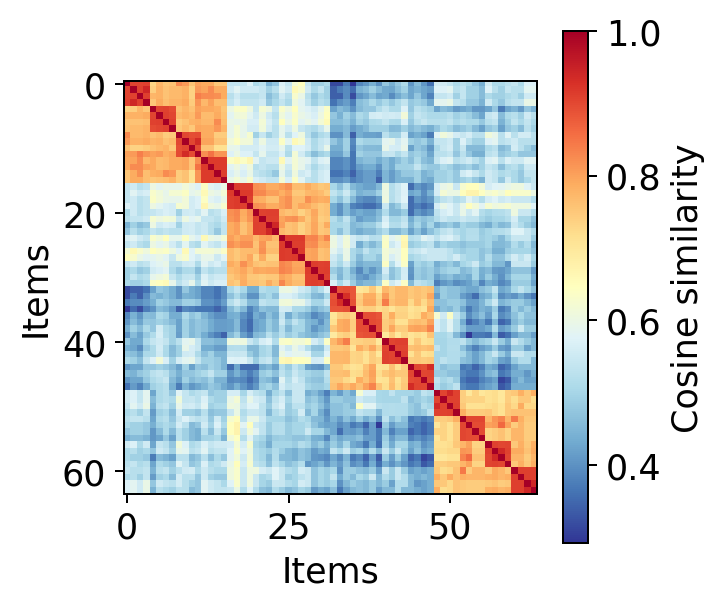

0.4921875


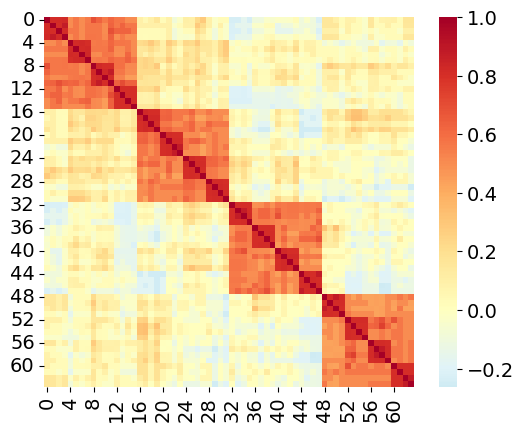

In [50]:
import seaborn as sns

# '''generate patterns with 2 levels of Hierarchy
#     4 level 1 nodes - prototypes
#     4 leafs per prototypes
#     4x4 = 16 instances in total
# '''
# dim = 64
# n1 = 4
# n2 = 1
# n3 = 4
# p1 = 0
# p2 = .1

# bup = HierarchicalBinaryPatterns(dim=dim, n1=n1,n2=n2,n3=n3, p1=p1, p2=p2)

# f, ax = plt.subplots()
# RSM = np.corrcoef(bup.data)
# sns.heatmap(RSM, square=True, cmap='RdYlBu_r', center=0)

# f, ax = plt.subplots()
# RSM = np.corrcoef(bup.data)
# sns.heatmap(RSM, square=True, cmap='RdYlBu_r', center=0)


'''generate patterns with 3 levels of Hierarchy
    4 level 1 nodes - prototypes
    4 level 2 nodes per every prototype
    4 level 3 nodes / leafs per level 2 node
    4x4x4 = 64 instances in total
'''
dim = 64
n1 = 4
n2 = 4
n3 = 4
p1 = .1
p2 = .05

bup = HierarchicalBinaryPatterns(dim=dim, n1=n1,n2=n2,n3=n3, p1=p1, p2=p2)

# f, ax = plt.subplots()
plt.figure(figsize=(3.7, 3.7), dpi=180)
RSM = np.corrcoef(bup.data)
RSM = cosine_similarity(bup.data)
plt.imshow(RSM, cmap="RdYlBu_r")
# sns.heatmap(RSM, square=True, cmap='RdYlBu_r', center=0)
plt.xlabel("Items")
plt.ylabel("Items")
plt.colorbar(label="Cosine similarity")
plt.show()
plt.close()

f, ax = plt.subplots()
RSM = np.corrcoef(bup.data)
sns.heatmap(RSM, square=True, cmap='RdYlBu_r', center=0)

print(np.mean(bup.data))

In [ ]:
plt.imshow()

(64, 64)
0.5078125


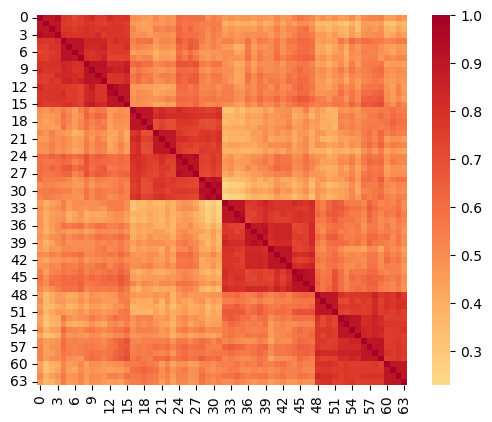

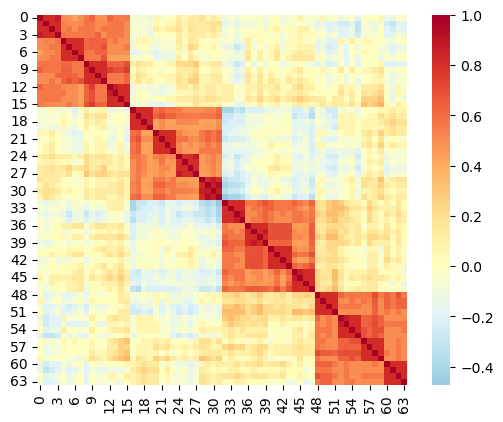

In [21]:
from tasks.utils import hierarchical_binary_patterns

relation_matrix, data = hierarchical_binary_patterns(dim=64, n1=4, n2=4, n3=4, p1=.1, p2=.05)

print(data.shape)

f, ax = plt.subplots()
RSM = np.corrcoef(data)
RSM = cosine_similarity(data)
sns.heatmap(RSM, square=True, cmap='RdYlBu_r', center=0)

f, ax = plt.subplots()
RSM = np.corrcoef(data)
sns.heatmap(RSM, square=True, cmap='RdYlBu_r', center=0)

print(np.mean(data))

# np.save("./data/hierarchical_binary_patterns.npy", data)

0.9118649401351071 0.7786644831771904 0.5077585466900555
0.8934271123648286 0.6913011298202834 0.22978625750451445
0.9649012813540149 0.8827348295047501 0.7061878636037999


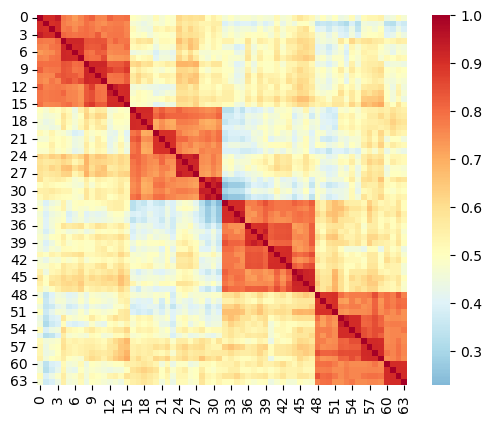

In [26]:
import seaborn as sns

data = np.load("./data/hierarchical_binary_patterns.npy")

f, ax = plt.subplots()
RSM = cosine_similarity(data)
sns.heatmap(RSM, square=True, cmap='RdYlBu_r', center=0.5)

sim0_data = []
sim1_data = []
sim2_data = []

for i in range(data.shape[0]):
    for j in range(i):
        if np.floor(i/4) == np.floor(j/4):
            sim0_data.append(RSM[i, j])
        elif np.floor(i/16) == np.floor(j/16):
            sim1_data.append(RSM[i, j])
        else:
            sim2_data.append(RSM[i, j])

sim0_data = np.array(sim0_data)
sim1_data = np.array(sim1_data)
sim2_data = np.array(sim2_data)

print(np.mean(sim0_data), np.mean(sim1_data), np.mean(sim2_data))
print(np.min(sim0_data), np.min(sim1_data), np.min(sim2_data))
print(np.max(sim0_data), np.max(sim1_data), np.max(sim2_data))


In [ ]:
# np.save("./data/hierarchical_binary_patterns.npy", data)

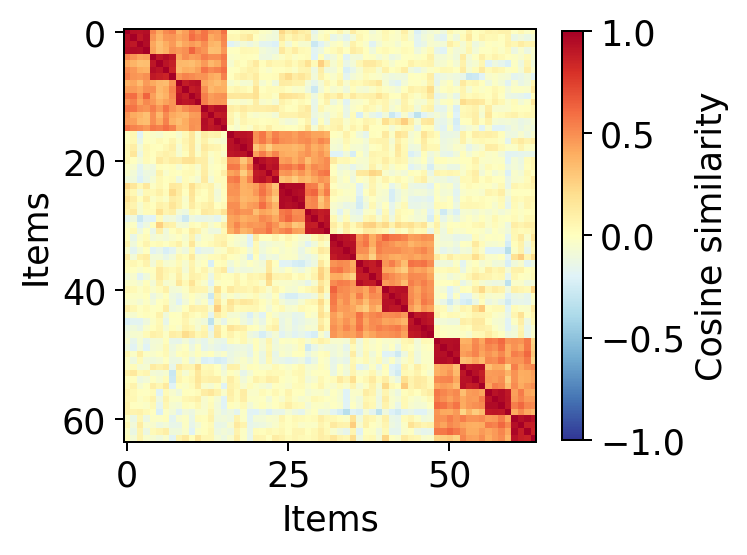

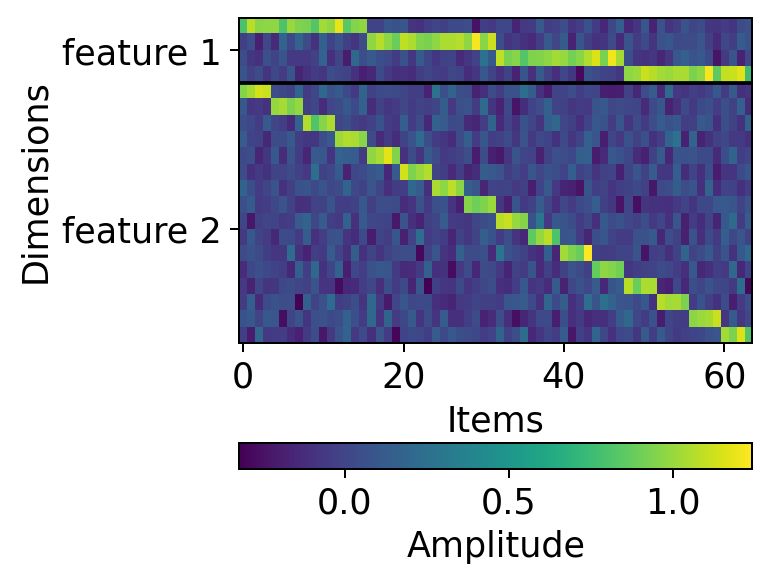

In [6]:
rumelhart_data = np.zeros((64, 20))

for i in range(64):
    feature1 = np.floor(i / 16)
    feature2 = np.floor(i / 4)
    rumelhart_data[i, int(feature1)] = 1
    rumelhart_data[i, int(4+feature2)] = 1

rumelhart_data = rumelhart_data + np.random.randn(64, 20) * 0.1

import seaborn as sns

plt.figure(figsize=(4.3, 3.7), dpi=180)
RSM = cosine_similarity(rumelhart_data)
plt.imshow(RSM, cmap="RdYlBu_r", vmin=-1, vmax=1)
# sns.heatmap(RSM, square=True, cmap='RdYlBu_r', center=0)
plt.xlabel("Items")
plt.ylabel("Items")
plt.colorbar(label="Cosine similarity", shrink=0.8)
plt.tight_layout()
savefig("./figures/exfig6", "exfig6D", format="svg", close=False)
plt.show()
plt.close()

plt.figure(figsize=(4.5, 3.5), dpi=180)
plt.imshow(rumelhart_data.T, cmap='viridis', aspect='auto')
plt.xlabel("Items")
plt.ylabel("Dimensions")
plt.colorbar(label="Amplitude", orientation='horizontal', pad=0.2)
plt.gca().set_yticks([3.5], minor=True)
plt.gca().tick_params(which='minor', length=0)
plt.gca().grid(visible=True, which='minor', color='black', linewidth=1.5)
plt.yticks([1.5, 12.5], ['feature 1', 'feature 2'])
plt.tight_layout()
savefig("./figures/exfig6", "exfig6C", format="svg", close=False)
plt.show()
plt.close()


In [ ]:
# np.save("./data/rumelhart_semantic_data.npy", rumelhart_data)

In [2]:
from tasks import FreeRecall

env = FreeRecall(num_features=4, feature_dim=2, sequence_len=4, retrieve_time_limit=None, reset_state_before_test=True, 
                correct_reward=1.0, wrong_reward=-1.0, no_action_reward=-1.0, 
                include_condition_during_encode=False, one_hot_stimuli=True, one_hot_action=True, 
                gaussian_stimuli=False, gaussian_stimuli_std=1.0, gaussian_stimuli_sigma=0.2, 
                include_extra_observation=True, extra_observation_type="gaussian", extra_observation_dim=11, 
                requires_extra_action=False, include_extra_observation_during_recall=True, different_extra_observation_during_recall=False, seed=None)

done = False
obs, info = env.reset()
t = 0
print("time step: ", t)
print(obs, info)
while not done:
    action = env.action_space.sample()
    obs, reward, _, _, info = env.step(action)
    done = info["done"]
    print("action: ", action, "reward: ", reward)
    print()
    t += 1
    print("time step: ", t)
    print(obs, info)



time step:  0
[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          1.          0.          0.
  0.          0.          0.          0.         -0.32393819 -0.32393819
 -0.32393819 -0.32393814 -0.28521366  3.16193276 -0.28521366 -0.32393814
 -0.32393819 -0.32393819 -0.32393819  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.        ] {'phase': 'encoding'}
action:  [0] reward:  0.0

time step:  1
[ 0.          0.          0.          0.          0.          0.
  1.          0.          0.          0.          0.          0.
  0.          0.          0.          0.         -0.32393819 -0.32393819
 -0.32393819 -0.32393819 -0.32393814 -0.28521366  3.16193276 -0.28521366
 -0.32393814 -0.32393819 -0.32393819  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.        ] {'phase': 'encoding', 'gt': array([10.]), 'gt_mask': True, 'loss_mask': True, 'corr